In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 모듈 자동 리로드 설정
%load_ext autoreload
%autoreload 2

# src 폴더 경로 설정
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

# 공통 함수 모듈 임포트
from src import common_utils as utils
from src import config

# 머신러닝 관련 임포트
from xgboost import XGBClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, OrdinalEncoder  # [수정] OneHot -> Ordinal
from sklearn.compose import ColumnTransformer

utils.log("✅ 환경 설정 완료")

[09:23:41] ✅ [Config] 환경 설정 완료 (OS: Windows)
[09:23:42] ✅ 환경 설정 완료


In [2]:
# 1. 파일 경로 및 기간 설정
FILE_PATH = "../../data/10_processed/df_sha.parquet"
TRAIN_MONTHS = [str(202300 + i) for i in range(2, 11)] # 2~10월
TEST_MONTHS = ['202311', '202312']                     # 11~12월

# 2. 데이터 로드
df = utils.load_parquet(FILE_PATH)

# 3. 전처리 (값 변환 -> 타입 변경 -> 이름 변경)
df = utils.data_preprocess(df)

# 4. 결측치 제거
df = df.dropna()
utils.log(f"✅ 전처리 및 결측치 제거 완료: {len(df):,}건")

[09:24:13] 📂 로드 완료: 22,473,534 Rows (Selected 39 Columns)
[09:24:13] 🚀 데이터 전처리(data_preprocess) 시작...
[09:25:04] ✨ 전처리 완료: 37개 컬럼 변환 및 정리됨
[09:25:25] ✅ 전처리 및 결측치 제거 완료: 19,363,972건


In [3]:
# 1. Train/Test 분리 및 다운샘플링 (비율 1:3)
target_col_name = 'derived_cancel_yn' # config에 맞게 수정

X_train_full, y_train_full, X_test, y_test = utils.split_oot_dataset(
    df, 
    train_months=TRAIN_MONTHS, 
    test_months=TEST_MONTHS,
    target_col=target_col_name,
    sampling_ratio=3.0 
)

print(f"📌 전체 학습 데이터: {X_train_full.shape}")

# [핵심 수정] RFECV를 위해 학습 데이터 추가 샘플링 (10%만 사용)
# 360만 건으로 RFECV를 돌리면 며칠이 걸릴 수 있습니다. 특성 선택에는 10~30만 건이면 충분합니다.
SAMPLE_RATE_FOR_RFECV = 0.1  # 10% 사용

X_train = X_train_full.sample(frac=SAMPLE_RATE_FOR_RFECV, random_state=42)
y_train = y_train_full.loc[X_train.index]

print(f"📉 RFECV용 샘플링 데이터: {X_train.shape} (전체의 {SAMPLE_RATE_FOR_RFECV*100}%)")
print(f"📌 검증 데이터(Test):  {X_test.shape}")

[09:25:26] 🚀 데이터셋 분할(split_oot_dataset) 시작...
[09:25:39] 📊 분할 결과: Train 15,868,607건 (기간: 202302~202310), Test 3,495,365건
[09:25:52] ✂️ 다운샘플링 적용 (비율 1:3.0): Train 데이터가 3,676,120건으로 조정됨


📌 전체 학습 데이터: (3676120, 36)
📉 RFECV용 샘플링 데이터: (367612, 36) (전체의 10.0%)
📌 검증 데이터(Test):  (3495365, 36)


In [4]:
# 1. 컬럼 분류
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

# 2. [수정] 변환기 정의 (OrdinalEncoder 사용)
# XGBoost 같은 트리 모델은 OneHot(수천 개 컬럼)보다 Ordinal(숫자 매핑)이 메모리 효율적이고 성능도 잘 나옵니다.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        # handle_unknown='use_encoded_value': 모르는 카테고리가 나오면 -1로 처리
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
    ],
    verbose_feature_names_out=False
)

# 3. 데이터 변환 수행
print("🔄 데이터 인코딩 및 스케일링 변환 중...")

# Train 데이터 변환
X_train_encoded = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()

# DataFrame으로 변환 (Ordinal을 썼기 때문에 컬럼 수가 늘어나지 않아 OOM 안 생김)
X_train_df = pd.DataFrame(X_train_encoded, columns=feature_names, index=X_train.index)

# Test 데이터 변환
X_test_encoded = preprocessor.transform(X_test)
X_test_df = pd.DataFrame(X_test_encoded, columns=feature_names, index=X_test.index)

print(f"✅ 변환 완료! 특성 개수 유지됨: {X_train_df.shape[1]}개 (OneHot 대비 대폭 감소)")

🔄 데이터 인코딩 및 스케일링 변환 중...
✅ 변환 완료! 특성 개수 유지됨: 36개 (OneHot 대비 대폭 감소)


In [5]:
# ==========================================================
# RFECV 설정 및 실행
# ==========================================================

# 1. 모델 설정 
xgb_model = XGBClassifier(
    random_state=42, 
    n_estimators=50, 
    max_depth=5,        # 깊이를 줄여 속도 향상
    eval_metric='logloss',
    enable_categorical=True, # 범주형 데이터 처리 최적화
    n_jobs=-1
)

# 2. RFECV 설정
rfecv = RFECV(
    estimator=xgb_model,
    step=1,                 # 특성이 적으므로 1개씩 제거해도 됨
    cv=StratifiedKFold(3),  # 3-Fold
    scoring='recall',       # 탐지율 최적화
    min_features_to_select=5, 
    n_jobs=-1
)

print(f"🚀 RFECV 특성 선택 시작... (데이터 {len(X_train_df):,}건)")
rfecv.fit(X_train_df, y_train)

print(f"✅ RFECV 완료! 최적의 특성 개수: {rfecv.n_features_}")

🚀 RFECV 특성 선택 시작... (데이터 367,612건)
✅ RFECV 완료! 최적의 특성 개수: 17


🎯 선택된 특성 (17개):
['DERIVED_PAID_CHNL_CNT_GRP', 'DERIVED_INHOME_RATE', 'DERIVED_TOTAL_USED_DAYS', 'DERIVED_TOTAL_INTERNET_SCRB', 'DERIVED_GIGA_INTERNET_SCRB', 'DERIVED_MEDIA_NM_GRP', 'DERIVED_PROD_NM_GRP', 'DERIVED_AGMT_KIND_NM', 'DERIVED_STB_RES_1M_YN', 'DERIVED_AGMT_END_SEG', 'DERIVED_AGMT_END_YMD', 'DERIVED_CH_LAST_DAYS_BF_GRP', 'DERIVED_VOC_TOTAL_MONTH1_YN', 'DERIVED_VOC_STOP_CANCEL_MONTH1_YN', 'DERIVED_AGE_GRP10', 'DERIVED_EMAIL_RECV_CLS_NM', 'DERIVED_SMS_SEND_CLS_NM']

🗑️ 제거된 특성 (19개):
['DERIVED_SVOD_SCRB_CNT_GRP', 'DERIVED_TV_SCRB', 'DERIVED_ANALOG_SCRB', 'DERIVED_DIGITAL_SCRB', 'DERIVED_TV_I_CNT', 'DERIVED_CH_HH_AVG_MONTH1', 'DERIVED_CH_25_RATIO_MONTH1', 'DERIVED_CH_25_RATIO_MEAN_3MM', 'DERIVED_KIDS_USE_PV_MONTH1', 'DERIVED_SVC_USE_DAYS_GRP', 'DERIVED_PROD_OLD_YN', 'DERIVED_PROD_ONE_PLUS_YN', 'DERIVED_SCRB_PATH_NM_GRP', 'DERIVED_BUNDLE_YN', 'DERIVED_DIGITAL_GIGA_YN', 'DERIVED_DIGITAL_ALOG_YN', 'DERIVED_CH_FAV_RNK1', 'DERIVED_NFX_USE_YN', 'DERIVED_YTB_USE_YN']


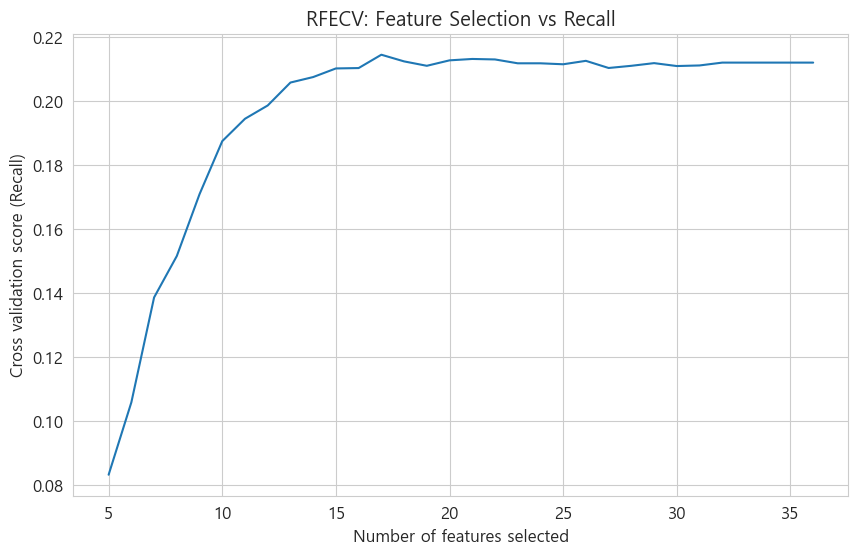

In [6]:
# 1. 선택된 특성 리스트
selected_features = X_train_df.columns[rfecv.support_]
print(f"🎯 선택된 특성 ({len(selected_features)}개):\n{list(selected_features)}")

# 2. 제거된 특성 리스트
dropped_features = X_train_df.columns[~rfecv.support_]
print(f"\n🗑️ 제거된 특성 ({len(dropped_features)}개):\n{list(dropped_features)}")

# 3. 성능 변화 시각화
plt.figure(figsize=(10, 6))
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (Recall)")
plt.plot(
    range(rfecv.min_features_to_select, len(rfecv.cv_results_['mean_test_score']) * rfecv.step + rfecv.min_features_to_select, rfecv.step),
    rfecv.cv_results_['mean_test_score']
)
plt.title("RFECV: Feature Selection vs Recall")
plt.grid(True)
plt.show()

🚀 최종 모델 재학습 중...

📊 최종 성능 평가 (11~12월 데이터)
✅ 정확도 (Accuracy):  0.9531
✅ 탐지율 (Recall):    0.1867  <-- ★핵심 지표
✅ F1 Score:          0.1765
✅ ROC AUC:           0.7452

[혼동 행렬 (Confusion Matrix)]


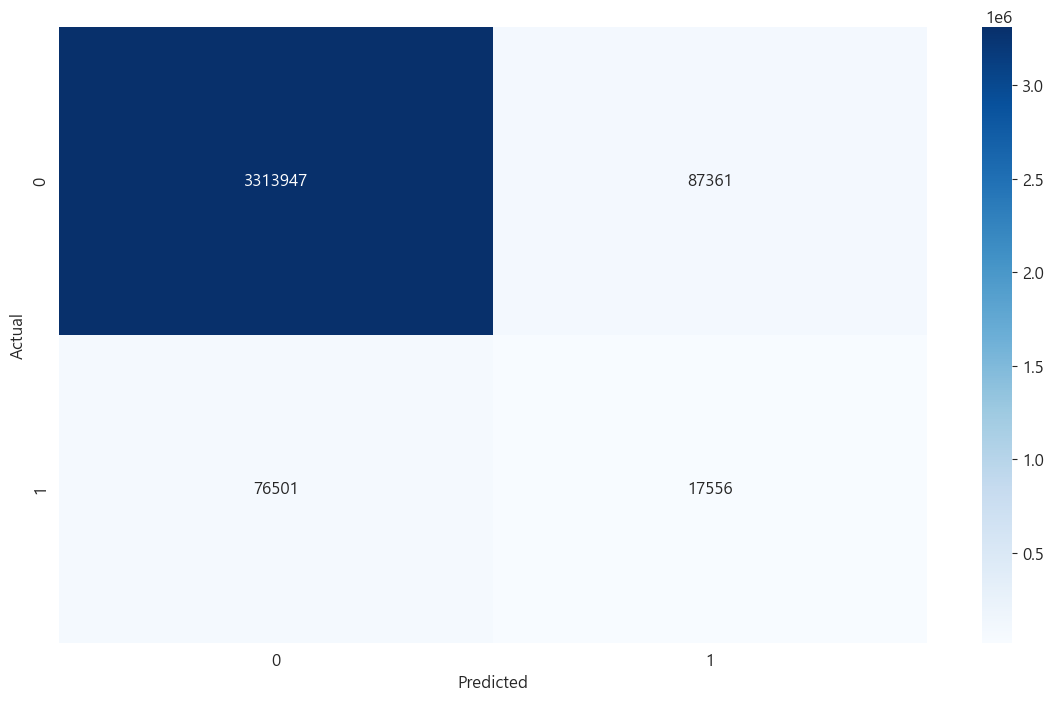

In [7]:
# ==========================================================
# 선택된 특성으로 최종 검증 (Test Data)
# ==========================================================

# 1. 선택된 특성만 남기기 (변환된 Test DF 사용)
X_train_final = X_train_df[selected_features]
X_test_final = X_test_df[selected_features]

# 2. 모델 재학습 
# (주의: 특성 선택은 샘플 데이터로 했지만, 최종 학습은 샘플링된 데이터로 가볍게 하거나 
#  시간이 허락하면 X_train_full을 변환해서 전체로 학습해도 됩니다. 여기선 샘플 데이터로 진행)
print("🚀 최종 모델 재학습 중...")
final_model = XGBClassifier(
    random_state=42, 
    n_estimators=100, 
    max_depth=6, 
    eval_metric='logloss', 
    enable_categorical=True,
    n_jobs=-1
)
final_model.fit(X_train_final, y_train)

# 3. 예측 및 평가
y_pred = final_model.predict(X_test_final)
y_prob = final_model.predict_proba(X_test_final)[:, 1]

# 4. 결과 출력
print("\n" + "="*50)
print("📊 최종 성능 평가 (11~12월 데이터)")
print("="*50)

acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print(f"✅ 정확도 (Accuracy):  {acc:.4f}")
print(f"✅ 탐지율 (Recall):    {rec:.4f}  <-- ★핵심 지표")
print(f"✅ F1 Score:          {f1:.4f}")
print(f"✅ ROC AUC:           {roc:.4f}")

print("\n[혼동 행렬 (Confusion Matrix)]")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



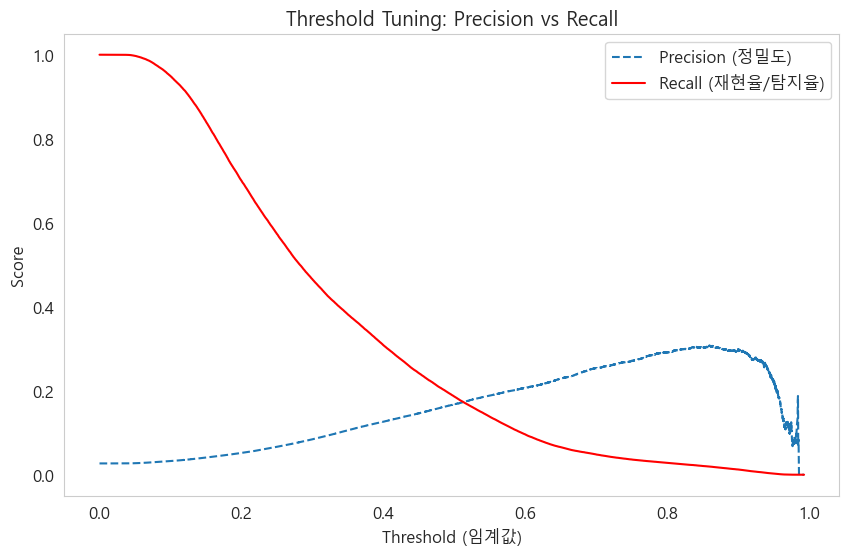

🎯 목표 탐지율 (60.0%) 달성을 위한 최적 임계값: 0.2398

📊 임계값 조정 후 성능 평가 (Threshold: 0.2398)
✅ 탐지율 (Recall):    0.1867  --->  0.6000 (🔺 대폭 상승)
✅ 정확도 (Accuracy):  0.7487
✅ F1 Score:          0.1139

[혼동 행렬 비교]


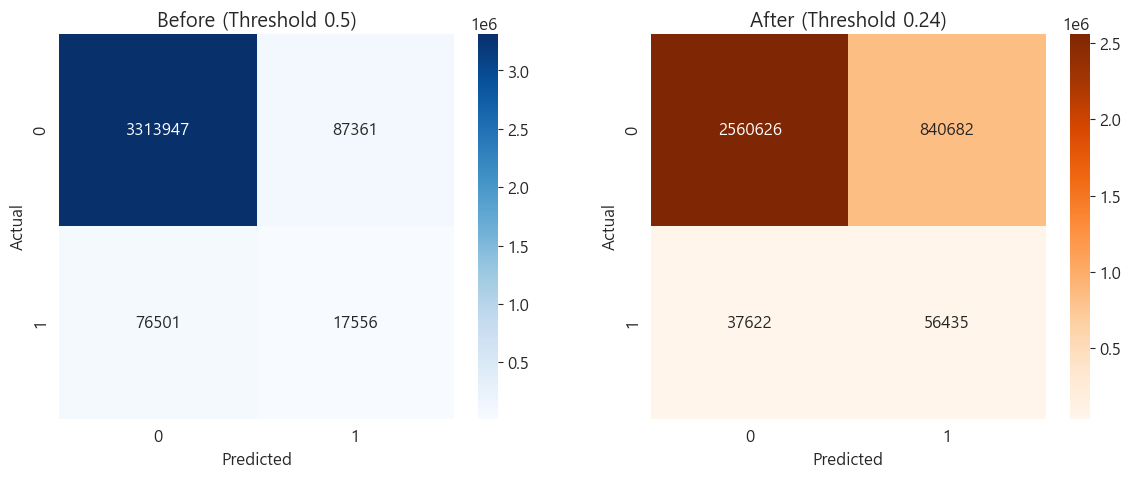

In [9]:
# ==========================================================
# [Cell 8] 임계값(Threshold) 튜닝으로 Recall 극대화하기
# ==========================================================
from sklearn.metrics import precision_recall_curve

# 1. 해지 확률값 추출 (변수명 수정: X_test_final 사용)
# Cell 7에서 만들어진 X_test_final을 사용해야 합니다.
y_prob = final_model.predict_proba(X_test_final)[:, 1]

# 2. 임계값별 정밀도-재현율 계산
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# 3. 임계값별 성능 변화 시각화
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], linestyle='--', label='Precision (정밀도)')
plt.plot(thresholds, recalls[:-1], color='red', label='Recall (재현율/탐지율)')
plt.xlabel('Threshold (임계값)')
plt.ylabel('Score')
plt.title('Threshold Tuning: Precision vs Recall')
plt.legend()
plt.grid()
plt.show()

# 4. 목표 Recall을 달성하는 최적의 임계값 찾기
# 목표: "최소한 해지자의 60% 이상은 찾아내자" (목표치는 상황에 따라 0.5~0.7로 조정 가능)
TARGET_RECALL = 0.6

# Recall이 목표치 이상인 지점들 중 가장 높은 임계값 찾기
valid_indices = np.where(recalls >= TARGET_RECALL)[0]
if len(valid_indices) > 0:
    optimal_idx = valid_indices[-1]
    optimal_threshold = thresholds[optimal_idx]
else:
    print("⚠️ 목표 Recall을 달성할 수 없습니다. 목표를 낮춰주세요.")
    optimal_threshold = 0.5

print(f"🎯 목표 탐지율 ({TARGET_RECALL*100}%) 달성을 위한 최적 임계값: {optimal_threshold:.4f}")

# 5. 최적 임계값 적용 후 성능 재평가
# 확률(y_prob)이 최적 임계값보다 크면 1(해지), 아니면 0(유지)
y_pred_tuned = (y_prob >= optimal_threshold).astype(int)

print("\n" + "="*50)
print(f"📊 임계값 조정 후 성능 평가 (Threshold: {optimal_threshold:.4f})")
print("="*50)

# 주요 지표 비교
# y_pred는 Cell 7에서 이미 계산된 값이 있어야 합니다. 
# 만약 없다면: y_pred = final_model.predict(X_test_final)
y_pred_default = final_model.predict(X_test_final) 

old_rec = recall_score(y_test, y_pred_default)
new_rec = recall_score(y_test, y_pred_tuned)
new_acc = accuracy_score(y_test, y_pred_tuned)
new_f1 = f1_score(y_test, y_pred_tuned)

print(f"✅ 탐지율 (Recall):    {old_rec:.4f}  --->  {new_rec:.4f} (🔺 대폭 상승)")
print(f"✅ 정확도 (Accuracy):  {new_acc:.4f}")
print(f"✅ F1 Score:          {new_f1:.4f}")

print("\n[혼동 행렬 비교]")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_default), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Before (Threshold 0.5)')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_tuned), annot=True, fmt='d', cmap='Oranges', ax=ax[1])
ax[1].set_title(f'After (Threshold {optimal_threshold:.2f})')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.show()